# Bayesian Wind-Tunnel Analysis for Tetris Rotation (Pipeline-Compatible)

This notebook creates a **Bayesian wind tunnel** for the Tetris rotation setup used in `pipeline_tetris.ipynb`.  
We generate synthetic Tetris shapes, reveal them through **partial rotation steps**, and compute the **exact Bayesian posterior** over `(shape, angle)` after each observation.  

We then compare that ground-truth posterior to a **coarser observer** (a proxy for a model that loses information), and measure entropy calibration error across steps.

You can later replace the coarse observer with your actual model (FM / PPO / DINO-based) by plugging its likelihood into the `model_log_likelihood(...)` function.

In [1]:
%cd /Users/masha/Documents/visual-reasoning

/Users/masha/Documents/visual-reasoning


In [2]:
import math
from typing import Dict, Tuple, List

import numpy as np
import cv2
import matplotlib.pyplot as plt

# Reproducibility
SEED = 0
rng = np.random.default_rng(SEED)

# Global config
IMG_SIZE = 64
ANGLE_STEP = 10
ANGLES = list(range(0, 360, ANGLE_STEP))
N_STEPS = 8  # number of partial observations in the trajectory
SIGMA_TRUE = 0.06  # noise scale for ground-truth likelihood
SIGMA_MODEL = 0.10  # noise scale for coarse observer
COARSE_SIZE = 16  # downsample size for coarse observer

In [3]:
# --- Tetris chiral shapes (same family as pipeline_tetris) ---
CHIRAL_SHAPES = {
    'L': [(0, -1), (0, 0), (0, 1), (1, 1)],
    'J': [(0, -1), (0, 0), (0, 1), (-1, 1)],
    'S': [(0, 0), (1, 0), (0, 1), (-1, 1)],
    'Z': [(0, 0), (-1, 0), (0, 1), (1, 1)],
    'F': [(0, 0), (0, -1), (1, -1), (-1, 0), (0, 1)],
    'P': [(0, 0), (0, -1), (1, -1), (1, 0), (0, 1)],
}

SHAPE_KEYS = list(CHIRAL_SHAPES.keys())


def draw_shape_np(name: str, size: int = IMG_SIZE) -> np.ndarray:
    img = np.zeros((size, size), dtype=np.uint8)
    center = size // 2
    block_size = size // 8
    for dx, dy in CHIRAL_SHAPES[name]:
        x = center + (dx * block_size) - (block_size // 2)
        y = center + (dy * block_size) - (block_size // 2)
        cv2.rectangle(img, (x, y), (x + block_size, y + block_size), 255, -1)
    return img


def rotate_image(img: np.ndarray, angle_deg: float, bg: int = 0) -> np.ndarray:
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_NEAREST, borderValue=bg)


def make_trajectory(shape_name: str, angle_deg: float, steps: int = N_STEPS) -> List[np.ndarray]:
    base = draw_shape_np(shape_name, IMG_SIZE)
    fracs = np.linspace(0.0, 1.0, steps)
    frames = [rotate_image(base, angle_deg * f) for f in fracs]
    return frames

In [4]:
# --- Hypothesis bank ---

def build_hypothesis_bank(shape_keys: List[str], angles: List[int], size: int) -> Dict[Tuple[str, int], np.ndarray]:
    bank = {}
    for s in shape_keys:
        base = draw_shape_np(s, size)
        for a in angles:
            bank[(s, a)] = rotate_image(base, a)
    return bank


def downsample(img: np.ndarray, size: int) -> np.ndarray:
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)


HYP_BANK = build_hypothesis_bank(SHAPE_KEYS, ANGLES, IMG_SIZE)
HYP_BANK_COARSE = {k: downsample(v, COARSE_SIZE) for k, v in HYP_BANK.items()}

In [5]:
# --- Bayesian update utilities ---

def img_float(img: np.ndarray) -> np.ndarray:
    return img.astype(np.float32) / 255.0


def log_likelihood(obs: np.ndarray, hyp: np.ndarray, sigma: float) -> float:
    diff = img_float(obs) - img_float(hyp)
    mse = float(np.mean(diff ** 2))
    return -mse / (2.0 * sigma * sigma)


def normalize_log_probs(logp: np.ndarray) -> np.ndarray:
    m = np.max(logp)
    exp = np.exp(logp - m)
    return exp / np.sum(exp)


def posterior_update(prior: np.ndarray, obs: np.ndarray, bank: List[np.ndarray], sigma: float) -> np.ndarray:
    # bank is list of hypothesis images aligned with prior
    logp = np.array([math.log(p) + log_likelihood(obs, hyp, sigma) for p, hyp in zip(prior, bank)])
    return normalize_log_probs(logp)


def entropy_bits(p: np.ndarray) -> float:
    p = np.clip(p, 1e-12, 1.0)
    return float(-np.sum(p * np.log2(p)))

In [6]:
# --- Prepare aligned hypothesis lists for fast updates ---
HYP_KEYS = list(HYP_BANK.keys())
HYP_LIST = [HYP_BANK[k] for k in HYP_KEYS]
HYP_LIST_COARSE = [HYP_BANK_COARSE[k] for k in HYP_KEYS]


def uniform_prior(n: int) -> np.ndarray:
    return np.ones(n, dtype=np.float64) / n

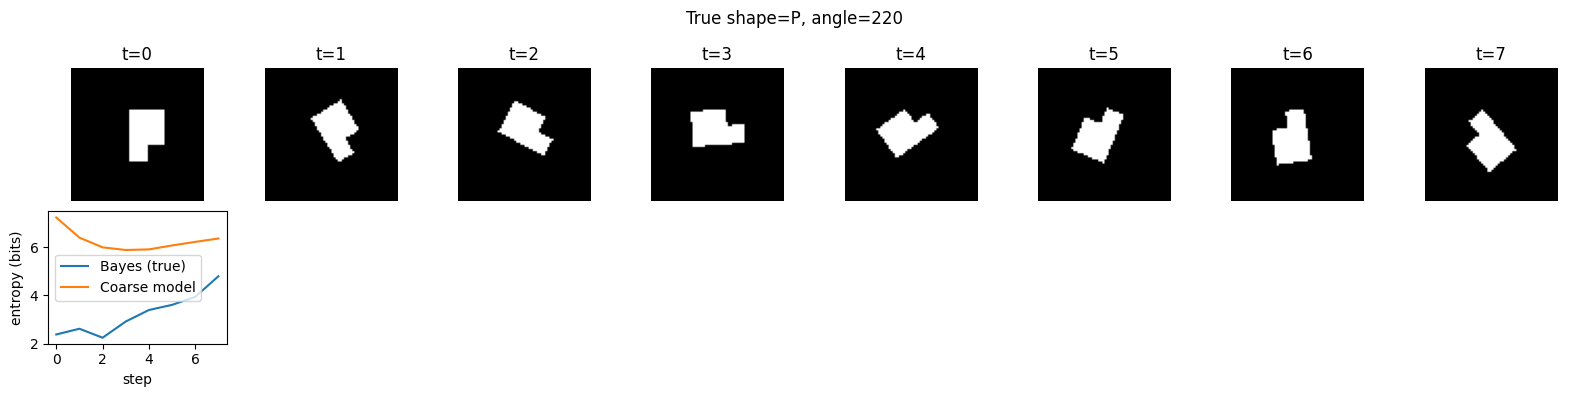

In [7]:
# --- Single example visualization ---
true_shape = rng.choice(SHAPE_KEYS)
true_angle = int(rng.choice(ANGLES))
frames = make_trajectory(true_shape, true_angle, steps=N_STEPS)

prior_true = uniform_prior(len(HYP_KEYS))
prior_model = uniform_prior(len(HYP_KEYS))

ent_true = []
ent_model = []

for obs in frames:
    prior_true = posterior_update(prior_true, obs, HYP_LIST, SIGMA_TRUE)
    # coarse observer (downsampled likelihood)
    obs_coarse = downsample(obs, COARSE_SIZE)
    prior_model = posterior_update(prior_model, obs_coarse, HYP_LIST_COARSE, SIGMA_MODEL)
    ent_true.append(entropy_bits(prior_true))
    ent_model.append(entropy_bits(prior_model))

# Plot frames + entropy
fig, axes = plt.subplots(2, N_STEPS, figsize=(2 * N_STEPS, 4))
for i, obs in enumerate(frames):
    axes[0, i].imshow(obs, cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f"t={i}")

axes[1, 0].plot(ent_true, label='Bayes (true)')
axes[1, 0].plot(ent_model, label='Coarse model')
axes[1, 0].set_xlabel("step")
axes[1, 0].set_ylabel("entropy (bits)")
axes[1, 0].legend()

# Hide unused subplots
for j in range(1, N_STEPS):
    axes[1, j].axis('off')

plt.suptitle(f"True shape={true_shape}, angle={true_angle}")
plt.tight_layout()
plt.show()

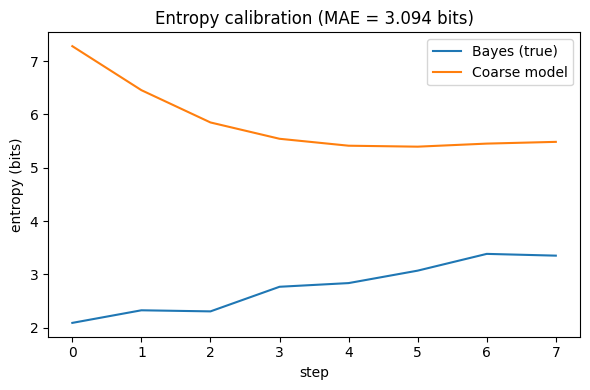

In [8]:
# --- Batch evaluation: entropy calibration ---

N_SAMPLES = 100

ent_true_all = []
ent_model_all = []

for _ in range(N_SAMPLES):
    shape = rng.choice(SHAPE_KEYS)
    angle = int(rng.choice(ANGLES))
    frames = make_trajectory(shape, angle, steps=N_STEPS)

    p_true = uniform_prior(len(HYP_KEYS))
    p_model = uniform_prior(len(HYP_KEYS))

    ent_true = []
    ent_model = []

    for obs in frames:
        p_true = posterior_update(p_true, obs, HYP_LIST, SIGMA_TRUE)
        obs_coarse = downsample(obs, COARSE_SIZE)
        p_model = posterior_update(p_model, obs_coarse, HYP_LIST_COARSE, SIGMA_MODEL)
        ent_true.append(entropy_bits(p_true))
        ent_model.append(entropy_bits(p_model))

    ent_true_all.append(ent_true)
    ent_model_all.append(ent_model)

ent_true_all = np.array(ent_true_all)
ent_model_all = np.array(ent_model_all)

mean_true = ent_true_all.mean(axis=0)
mean_model = ent_model_all.mean(axis=0)
mae = np.mean(np.abs(mean_true - mean_model))

plt.figure(figsize=(6, 4))
plt.plot(mean_true, label='Bayes (true)')
plt.plot(mean_model, label='Coarse model')
plt.xlabel("step")
plt.ylabel("entropy (bits)")
plt.title(f"Entropy calibration (MAE = {mae:.3f} bits)")
plt.legend()
plt.tight_layout()
plt.show()

## Plugging in your actual model

To replace the coarse observer with your own model (FM or PPO):

1. Define a function that returns a **log-likelihood** (or score) of the observation given a hypothesis `(shape, angle)`.  
2. Use that score inside `posterior_update(...)` instead of the downsampled likelihood.  

This gives you a clean, per-step **entropy calibration** metric you can compare across models or training regimes.